# Model Comparison — Telecom Customer Churn

This notebook establishes the model-comparison workflow.

Objectives:
- Reuse the production data-preparation code in src/
- Reuse the stratified train/test split
- Reuse the leakage-safe preprocessing pipeline
- Evaluate candidate models using stratified out-of-fold predictions
- Evaluate the final candidate on the held-out test set
- Verify that the comparison framework reproduces the existing
  Logistic Regression baseline before introducing additional models

In [1]:
from pathlib import Path
import sys
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.preprocessing import (
    build_preprocessor,
    load_raw_data,
    prepare_dataset,
)
from src.data.split import create_train_test_split
from src.modeling.comparison import (
    evaluate_model_cv,
    fit_and_evaluate_test,
)

In [2]:
df = load_raw_data()

X, y = prepare_dataset(df)

X_train, X_test, y_train, y_test = create_train_test_split(
    X,
    y,
)

print(f'Training rows: {len(X_train)}')
print(f'Test rows: {len(X_test)}')
print(f'Training churn rate: {y_train.mean():.6f}')
print(f'Test churn rate: {y_test.mean():.6f}')

Training rows: 6762
Test rows: 1691
Training churn rate: 0.064922
Test churn rate: 0.065050


In [3]:
logistic_regression = Pipeline(
    steps=[
        ('preprocessor', build_preprocessor(scale_numeric=True)),
        ('classifier', LogisticRegression(max_iter=1000, random_state=42))
    ])

In [4]:
logistic_cv_result = evaluate_model_cv(
    model=logistic_regression,
    X=X_train,
    y=y_train
)

logistic_cv_result['metrics']

{'PR-AUC': 0.08264539890467607, 'ROC-AUC': 0.5671707981527467}

In [5]:
logistic_test_result = fit_and_evaluate_test(
    model=logistic_regression,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    threshold=0.06
)

logistic_test_result['metrics']

Threshold              0.060000
PR-AUC                 0.082143
ROC-AUC                0.559192
Precision              0.070406
Recall                 0.536364
F1                     0.124473
Customers Flagged    838.000000
Coverage               0.495565
dtype: float64

In [6]:
comparison = pd.DataFrame(
    {
        'Logistic Regression': logistic_test_result['metrics']
    }
).T

comparison

,Threshold,PR-AUC,ROC-AUC,Precision,Recall,F1,Customers Flagged,Coverage
Logistic Regression,0.06,0.082143,0.559192,0.070406,0.536364,0.124473,838.0,0.495565


In [7]:
from sklearn.ensemble import RandomForestClassifier

In [8]:
random_forest = Pipeline(
    steps=[
        ('preprocessor', build_preprocessor(scale_numeric=False)),
        ('classifier', RandomForestClassifier(
                n_estimators=300,
                max_depth=None,
                min_samples_leaf=5,
                class_weight='balanced',
                random_state=42,
                n_jobs=-1
            ))
    ]
)

In [9]:
random_forest_cv_result = evaluate_model_cv(
    model=random_forest,
    X=X_train,
    y=y_train,
)

random_forest_cv_result['metrics']

{'PR-AUC': 0.0806682669996597, 'ROC-AUC': 0.5618054922604211}

In [10]:
random_forest_test_result = fit_and_evaluate_test(
    model=random_forest,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    threshold=0.06,
)

random_forest_test_result['metrics']

Threshold               0.060000
PR-AUC                  0.083352
ROC-AUC                 0.566592
Precision               0.065050
Recall                  1.000000
F1                      0.122154
Customers Flagged    1691.000000
Coverage                1.000000
dtype: float64

In [11]:
comparison = pd.DataFrame(
    {
        'Logistic Regression': logistic_test_result['metrics'],
        'Random Forest': random_forest_test_result['metrics'],
    }
).T

comparison

,Threshold,PR-AUC,ROC-AUC,Precision,Recall,F1,Customers Flagged,Coverage
Logistic Regression,0.06,0.082143,0.559192,0.070406,0.536364,0.124473,838.0,0.495565
Random Forest,0.06,0.083352,0.566592,0.065050,1.000000,0.122154,1691.0,1.000000


In [12]:
rf_proba = random_forest_test_result['test_probabilities']

pd.Series(rf_proba).describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

count    1691.000000
mean        0.395386
std         0.118971
min         0.123477
1%          0.175563
5%          0.217697
10%         0.248615
25%         0.302554
50%         0.386784
75%         0.475490
90%         0.554441
95%         0.605230
99%         0.697157
max         0.802524
dtype: float64

In [13]:
print(f'Minimum probability: {rf_proba.min():.6f}')
print(f'Maximum probability: {rf_proba.max():.6f}')
print(f'Probability >= 0.06: {(rf_proba >= 0.06).mean():.6f}')

Minimum probability: 0.123477
Maximum probability: 0.802524
Probability >= 0.06: 1.000000


In [14]:
comparison['Threshold'] = comparison['Threshold'].astype(float)
comparison

,Threshold,PR-AUC,ROC-AUC,Precision,Recall,F1,Customers Flagged,Coverage
Logistic Regression,0.06,0.082143,0.559192,0.070406,0.536364,0.124473,838.0,0.495565
Random Forest,0.06,0.083352,0.566592,0.065050,1.000000,0.122154,1691.0,1.000000


> The 0.06 threshold was established during Logistic Regression
> validation. It is shown here for reference and is not assumed to
> be an appropriate production threshold for Random Forest.
> Model ranking is therefore based primarily on threshold-independent
> probability metrics such as PR-AUC and ROC-AUC at this stage.

In [15]:
from src.modeling.thresholds import evaluate_thresholds

rf_oof_proba = random_forest_cv_result['oof_predictions']

rf_threshold_results = evaluate_thresholds(
    y_true=y_train,
    y_proba=rf_oof_proba,
    thresholds=[
        0.05,
        0.10,
        0.15,
        0.20,
        0.25,
        0.30,
        0.35,
        0.40,
        0.45,
        0.50,
        0.55,
        0.60,
    ],
)

rf_threshold_results.sort_values(
    'F1',
    ascending=False,
)

,Threshold,Precision,Recall,F1,Coverage,Customers Flagged
6,0.35,0.077235,0.694761,0.139015,0.583999,3949
7,0.40,0.077309,0.526196,0.134812,0.441881,2988
8,0.45,0.079403,0.375854,0.131108,0.307306,2078
9,0.50,0.085980,0.252847,0.128324,0.190920,1291
5,0.30,0.069508,0.794989,0.127839,0.742532,5021
4,0.25,0.065772,0.915718,0.122729,0.903875,6112
3,0.20,0.065283,0.981777,0.122426,0.976338,6602
0,0.05,0.064922,1.000000,0.121928,1.000000,6762
1,0.10,0.064922,1.000000,0.121928,1.000000,6762
2,0.15,0.064927,0.997722,0.121921,0.997634,6746


In [16]:
rf_test_at_035 = fit_and_evaluate_test(
    model=random_forest,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    threshold=0.35,
)

rf_test_at_035['metrics']

Threshold               0.350000
PR-AUC                  0.083352
ROC-AUC                 0.566592
Precision               0.076550
Recall                  0.718182
F1                      0.138354
Customers Flagged    1032.000000
Coverage                0.610290
dtype: float64

In [17]:
comparison_thresholded = pd.DataFrame(
    {
        'Logistic Regression': logistic_test_result['metrics'],
        'Random Forest': rf_test_at_035['metrics'],
    }
).T

comparison_thresholded

,Threshold,PR-AUC,ROC-AUC,Precision,Recall,F1,Customers Flagged,Coverage
Logistic Regression,0.06,0.082143,0.559192,0.070406,0.536364,0.124473,838.0,0.495565
Random Forest,0.35,0.083352,0.566592,0.076550,0.718182,0.138354,1032.0,0.610290


In [18]:
from sklearn.ensemble import HistGradientBoostingClassifier

In [19]:
hist_gradient_boosting = Pipeline(
    steps=[
        ('preprocessor', build_preprocessor(scale_numeric=True)),

        ('classifier', 
        HistGradientBoostingClassifier(
            max_iter=1000,
            learning_rate=0.05,
            max_leaf_nodes=15,
            min_samples_leaf=20,
            l2_regularization=1.0,
            random_state=42
        ))
    ])

In [20]:
hist_gb_cv_result = evaluate_model_cv(
    model=hist_gradient_boosting,
    X=X_train,
    y=y_train,
)

hist_gb_cv_result['metrics']

{'PR-AUC': 0.07964467864672728, 'ROC-AUC': 0.5389886220065805}

In [21]:
hist_gb_oof_proba = hist_gb_cv_result['oof_predictions']

pd.Series(hist_gb_oof_proba).describe(
    percentiles=[
        0.01,
        0.05,
        0.10,
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99,
    ]
)

count    6762.000000
mean        0.059730
std         0.084859
min         0.000058
1%          0.000598
5%          0.002844
10%         0.005367
25%         0.013158
50%         0.031511
75%         0.070692
90%         0.142812
95%         0.208367
99%         0.446305
max         0.913269
dtype: float64

In [22]:
hist_gb_threshold_results = evaluate_thresholds(
    y_true=y_train,
    y_proba=hist_gb_oof_proba,
    thresholds=[
        0.05,
        0.10,
        0.15,
        0.20,
        0.25,
        0.30,
        0.35,
        0.40,
        0.45,
        0.50,
        0.55,
        0.60,
    ],
)

hist_gb_threshold_results.sort_values(
    'F1',
    ascending=False,
)

,Threshold,Precision,Recall,F1,Coverage,Customers Flagged
0,0.05,0.076468,0.412301,0.129009,0.350044,2367
1,0.10,0.083627,0.216401,0.120635,0.167998,1136
2,0.15,0.095779,0.134396,0.111848,0.091097,616
3,0.20,0.106267,0.088838,0.096774,0.054274,367
4,0.25,0.104839,0.059226,0.075691,0.036676,248
5,0.30,0.117647,0.045558,0.065681,0.025140,170
6,0.35,0.115702,0.031891,0.050000,0.017894,121
7,0.40,0.133333,0.027335,0.045369,0.013310,90
8,0.45,0.166667,0.025057,0.043564,0.009760,66
9,0.50,0.187500,0.020501,0.036961,0.007098,48


### HistGradientBoosting baseline

The initial HistGradientBoosting configuration produced lower OOF
PR-AUC and ROC-AUC than the Logistic Regression and Random Forest
baselines. Its probability distribution also differs substantially
from the other models, so thresholds are model-specific.

The threshold grid produced a maximum observed OOF F1 of 0.129009
at threshold 0.05. This threshold is treated as a validation
diagnostic and is not yet a production decision.

In [23]:
cv_comparison = pd.DataFrame(
    {
        'Logistic Regression': logistic_cv_result['metrics'],
        'Random Forest': random_forest_cv_result['metrics'],
        'HistGradientBoosting': hist_gb_cv_result['metrics'],
    }
).T

cv_comparison.sort_values(
    'PR-AUC',
    ascending=False,
)

,PR-AUC,ROC-AUC
Logistic Regression,0.082645,0.567171
Random Forest,0.080668,0.561805
HistGradientBoosting,0.079645,0.538989


In [24]:
model_summary = pd.DataFrame(
    [
        {
            'Model': 'Logistic Regression',
            'Model Type': 'Linear',
            'Scaling': True,
            'Class Weight': 'None',
        },
        {
            'Model': 'Random Forest',
            'Model Type': 'Bagging / Trees',
            'Scaling': False,
            'Class Weight': 'Balanced',
        },
        {
            'Model': 'HistGradientBoosting',
            'Model Type': 'Gradient Boosting / Trees',
            'Scaling': False,
            'Class Weight': 'None',
        },
    ]
)

model_summary

,Model,Model Type,Scaling,Class Weight
0,Logistic Regression,Linear,True,None
1,Random Forest,Bagging / Trees,False,Balanced
2,HistGradientBoosting,Gradient Boosting / Trees,False,None


In [25]:
from src.modeling.tuning import tune_model

logistic_regression = Pipeline(
    steps=[
        ('preprocessor', build_preprocessor(scale_numeric=True)),
        ('classifier', LogisticRegression(max_iter=1000, random_state=42))
    ]
)

logistic_param_grid = {
    'classifier__C': [0.01, 0.1, 1.0, 10.0, 100.0],
}

logistic_search = tune_model(model=logistic_regression, param_grid=logistic_param_grid, X_train=X_train, y_train=y_train)

print('Best Logistic Regression parameters:')
print(logistic_search.best_params_)
print()
print('Best CV PR-AUC:')
print(logistic_search.best_score_)

Best Logistic Regression parameters:
{'classifier__C': 0.01}

Best CV PR-AUC:
0.09232340660582934


In [26]:
random_forest = Pipeline(
    steps=[
        ('preprocessor', build_preprocessor(scale_numeric=False)),
        ('classifier', RandomForestClassifier(
            class_weight='balanced',
            random_state=42,
            n_jobs=-1,
        )),
    ]
)

random_forest_param_grid = {
    'classifier__n_estimators': [200, 500],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_leaf': [2, 5, 10]
}

random_forest_search = tune_model(
    model=random_forest,
    param_grid=random_forest_param_grid,
    X_train=X_train,
    y_train=y_train,
)

print('Best Random Forest parameters:')
print(random_forest_search.best_params_)
print()
print('Best CV PR-AUC:')
print(random_forest_search.best_score_)

Best Random Forest parameters:
{'classifier__max_depth': 10, 'classifier__min_samples_leaf': 10, 'classifier__n_estimators': 500}

Best CV PR-AUC:
0.0954449104071666


In [27]:
tuned_cv_comparison = pd.DataFrame([
    {
        'Model': 'Logistic Regression Tuned',
        'CV PR-AUC': logistic_search.best_score_,
        'Best Parameters': logistic_search.best_params_,
    },
    {
        'Model': 'Random Forest Tuned',
        'CV PR-AUC': random_forest_search.best_score_,
        'Best Parameters': random_forest_search.best_params_,
    },
])

tuned_cv_comparison

,Model,CV PR-AUC,Best Parameters
0,Logistic Regression Tuned,0.092323,{'classifier__C': 0.01}
1,Random Forest Tuned,0.095445,"{'classifier__max_depth': 10, 'classifier__min..."


In [28]:
tuned_logistic_test = fit_and_evaluate_test(
    model=logistic_search.best_estimator_,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    threshold=0.06,
)

tuned_logistic_test['metrics']

Threshold              0.060000
PR-AUC                 0.079787
ROC-AUC                0.557789
Precision              0.073200
Recall                 0.563636
F1                     0.129572
Customers Flagged    847.000000
Coverage               0.500887
dtype: float64

In [29]:
tuned_random_forest_test = fit_and_evaluate_test(
    model=random_forest_search.best_estimator_,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    threshold=0.35,
)

tuned_random_forest_test['metrics']

Threshold               0.350000
PR-AUC                  0.082791
ROC-AUC                 0.563366
Precision               0.066710
Recall                  0.927273
F1                      0.124466
Customers Flagged    1529.000000
Coverage                0.904199
dtype: float64

In [30]:
tuned_test_comparison = pd.DataFrame([
    {
        'Model': 'Logistic Regression Tuned',
        **tuned_logistic_test['metrics'].to_dict(),
    },
    {
        'Model': 'Random Forest Tuned',
        **tuned_random_forest_test['metrics'].to_dict(),
    },
])

tuned_test_comparison

,Model,Threshold,PR-AUC,ROC-AUC,Precision,Recall,F1,Customers Flagged,Coverage
0,Logistic Regression Tuned,0.06,0.079787,0.557789,0.07320,0.563636,0.129572,847.0,0.500887
1,Random Forest Tuned,0.35,0.082791,0.563366,0.06671,0.927273,0.124466,1529.0,0.904199


In [31]:
hist_gradient_boosting_test = fit_and_evaluate_test(
    model=hist_gradient_boosting,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    threshold=0.05,
)

hist_gradient_boosting_test['metrics']

Threshold              0.050000
PR-AUC                 0.089013
ROC-AUC                0.592640
Precision              0.092166
Recall                 0.545455
F1                     0.157687
Customers Flagged    651.000000
Coverage               0.384979
dtype: float64

In [32]:
hist_gradient_boosting_tuned = Pipeline(
    steps=[
        ("preprocessor", build_preprocessor(scale_numeric=False)),
        ("classifier", HistGradientBoostingClassifier(
            random_state=42,
        )),
    ]
)

hist_gradient_boosting_param_grid = {
    "classifier__max_iter": [200, 300],
    "classifier__learning_rate": [0.03, 0.05, 0.1],
    "classifier__max_leaf_nodes": [7, 15, 31],
    "classifier__min_samples_leaf": [10, 20, 50],
    "classifier__l2_regularization": [0.0, 1.0],
}

In [33]:
hist_gradient_boosting_search = tune_model(
    model=hist_gradient_boosting_tuned,
    param_grid=hist_gradient_boosting_param_grid,
    X_train=X_train,
    y_train=y_train,
)

print("Best HistGradientBoosting parameters:")
print(hist_gradient_boosting_search.best_params_)

print()
print("Best CV PR-AUC:")
print(hist_gradient_boosting_search.best_score_)

Best HistGradientBoosting parameters:
{'classifier__l2_regularization': 1.0, 'classifier__learning_rate': 0.03, 'classifier__max_iter': 300, 'classifier__max_leaf_nodes': 7, 'classifier__min_samples_leaf': 50}

Best CV PR-AUC:
0.0918992813806306


In [34]:
hgb_tuned_test = fit_and_evaluate_test(
    model=hist_gradient_boosting_tuned,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    threshold=0.05,
)

hgb_tuned_test['metrics']

Threshold              0.050000
PR-AUC                 0.087748
ROC-AUC                0.581634
Precision              0.079019
Recall                 0.527273
F1                     0.137441
Customers Flagged    734.000000
Coverage               0.434063
dtype: float64

In [35]:
hgb_cv_results = (
    pd.DataFrame(hist_gradient_boosting_search.cv_results_)
    .sort_values("rank_test_score")
)

hgb_cv_results[
    [
        "rank_test_score",
        "mean_test_score",
        "std_test_score",
        "param_classifier__max_iter",
        "param_classifier__learning_rate",
        "param_classifier__max_leaf_nodes",
        "param_classifier__min_samples_leaf",
        "param_classifier__l2_regularization",
    ]
].head(10)

,rank_test_score,mean_test_score,std_test_score,param_classifier__max_iter,param_classifier__learning_rate,param_classifier__max_leaf_nodes,param_classifier__min_samples_leaf,param_classifier__l2_regularization
65,1,0.091899,0.007572,300,0.03,7,50,1.0
74,2,0.091593,0.006511,200,0.05,7,50,1.0
56,3,0.091573,0.010073,200,0.03,7,50,1.0
11,4,0.091433,0.006295,300,0.03,7,50,0.0
5,5,0.090571,0.005001,200,0.03,15,50,0.0
2,6,0.090272,0.008395,200,0.03,7,50,0.0
20,7,0.090080,0.007130,200,0.05,7,50,0.0
29,8,0.089983,0.006725,300,0.05,7,50,0.0
83,9,0.089920,0.005083,300,0.05,7,50,1.0
84,10,0.089247,0.012023,300,0.05,15,10,1.0


In [36]:
hist_gradient_boosting_cv = evaluate_model_cv(
    model=hist_gradient_boosting,
    X=X_train,
    y=y_train,
)

hist_gradient_boosting_cv["metrics"]

{'PR-AUC': 0.07964467864672728, 'ROC-AUC': 0.5389886220065805}

In [37]:
def build_model_comparison_row(
    model_name: str,
    cv_metrics: dict,
    test_metrics: pd.Series | None = None,
    cv_roc_auc: bool = True,
) -> dict:
    row = {
        "Model": model_name,
        "CV PR-AUC": cv_metrics.get("PR-AUC"),
        "CV ROC-AUC": cv_metrics.get("ROC-AUC") if cv_roc_auc else None,
        "Threshold": None,
        "Test PR-AUC": None,
        "Test ROC-AUC": None,
        "Test F1": None,
        "Test Recall": None,
        "Test Precision": None,
        "Coverage": None,
    }

    if test_metrics is not None:
        row.update({
            "Threshold": test_metrics["Threshold"],
            "Test PR-AUC": test_metrics["PR-AUC"],
            "Test ROC-AUC": test_metrics["ROC-AUC"],
            "Test F1": test_metrics["F1"],
            "Test Recall": test_metrics["Recall"],
            "Test Precision": test_metrics["Precision"],
            "Coverage": test_metrics["Coverage"],
        })

    return row

In [38]:
final_model_comparison = pd.DataFrame([

    build_model_comparison_row(
        "Logistic Regression",
        logistic_cv_result["metrics"],
        logistic_test_result["metrics"],
    ),

    build_model_comparison_row(
        "Random Forest",
        random_forest_cv_result["metrics"],
        random_forest_test_result["metrics"],
    ),

    build_model_comparison_row(
        "HistGradientBoosting",
        hist_gradient_boosting_cv["metrics"],
        hist_gradient_boosting_test["metrics"],
    ),

    build_model_comparison_row(
        "Logistic Regression Tuned",
        {"PR-AUC": logistic_search.best_score_},
        tuned_logistic_test["metrics"],
        cv_roc_auc=False,
    ),

    build_model_comparison_row(
        "Random Forest Tuned",
        {"PR-AUC": random_forest_search.best_score_},
        tuned_random_forest_test["metrics"],
        cv_roc_auc=False,
    ),

    build_model_comparison_row(
        "HistGradientBoosting Tuned",
        {"PR-AUC": hist_gradient_boosting_search.best_score_},
        hgb_tuned_test["metrics"],
        cv_roc_auc=False,
    ),
])

final_model_comparison

,Model,CV PR-AUC,CV ROC-AUC,Threshold,Test PR-AUC,Test ROC-AUC,Test F1,Test Recall,Test Precision,Coverage
0,Logistic Regression,0.082645,0.567171,0.06,0.082143,0.559192,0.124473,0.536364,0.070406,0.495565
1,Random Forest,0.080668,0.561805,0.06,0.083352,0.566592,0.122154,1.000000,0.065050,1.000000
2,HistGradientBoosting,0.079645,0.538989,0.05,0.089013,0.592640,0.157687,0.545455,0.092166,0.384979
3,Logistic Regression Tuned,0.092323,NaN,0.06,0.079787,0.557789,0.129572,0.563636,0.073200,0.500887
4,Random Forest Tuned,0.095445,NaN,0.35,0.082791,0.563366,0.124466,0.927273,0.066710,0.904199
5,HistGradientBoosting Tuned,0.091899,NaN,0.05,0.087748,0.581634,0.137441,0.527273,0.079019,0.434063


## Final Model Comparison

Hyperparameter tuning improved cross-validation PR-AUC for both Logistic Regression
and Random Forest. However, the improvements did not translate uniformly to the
held-out test set.

The tuned Random Forest achieved the highest held-out PR-AUC among the tuned models,
while its selected threshold produced very high recall but also flagged most of the
test population. Therefore, model discrimination and intervention threshold must be
treated as separate decisions.

The results indicate that the dataset contains only modest predictive signal under
the current feature set. Further work should focus on probability calibration,
threshold/business-cost analysis, explainability, and the revenue-risk layer before
production deployment.

In [39]:
from src.modeling.calibration import (
    evaluate_calibration,
    create_calibration_table,
)

In [40]:
logistic_calibration = evaluate_calibration(
    y_true=y_train,
    y_proba=logistic_cv_result["oof_predictions"],
    n_bins=10,
)

random_forest_calibration = evaluate_calibration(
    y_true=y_train,
    y_proba=random_forest_cv_result["oof_predictions"],
    n_bins=10,
)

hist_gradient_boosting_calibration = evaluate_calibration(
    y_true=y_train,
    y_proba=hist_gradient_boosting_cv["oof_predictions"],
    n_bins=10,
)

In [41]:
calibration_comparison = pd.DataFrame(
    [
        {
            "Model": "Logistic Regression",
            "Brier Score": logistic_calibration["brier_score"],
        },
        {
            "Model": "Random Forest",
            "Brier Score": random_forest_calibration["brier_score"],
        },
        {
            "Model": "HistGradientBoosting",
            "Brier Score": hist_gradient_boosting_calibration["brier_score"],
        },
    ]
)

calibration_comparison

,Model,Brier Score
0,Logistic Regression,0.060551
1,Random Forest,0.179356
2,HistGradientBoosting,0.065957


In [42]:
hgb_calibration_table = create_calibration_table(
    y_true=y_train,
    y_proba=hist_gradient_boosting_cv["oof_predictions"],
    n_bins=10,
)

hgb_calibration_table

,Mean Predicted Probability,Observed Churn Rate
0,0.002807,0.059084
1,0.007925,0.057692
2,0.013262,0.057692
3,0.019648,0.051775
4,0.027081,0.069527
5,0.036441,0.050296
6,0.049918,0.072485
7,0.071025,0.068047
8,0.109958,0.068047
9,0.259026,0.094535


In [43]:
logistic_calibration_table = create_calibration_table(
    y_true=y_train,
    y_proba=logistic_cv_result["oof_predictions"],
    n_bins=10,
)

random_forest_calibration_table = create_calibration_table(
    y_true=y_train,
    y_proba=random_forest_cv_result["oof_predictions"],
    n_bins=10,
)

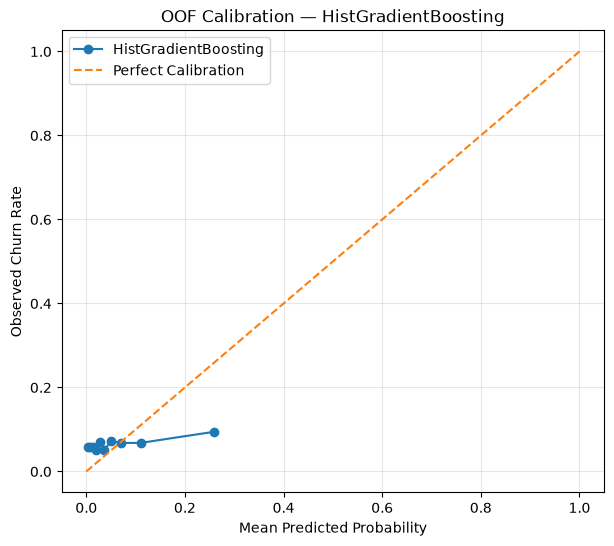

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.plot(
    hgb_calibration_table["Mean Predicted Probability"],
    hgb_calibration_table["Observed Churn Rate"],
    marker="o",
    label="HistGradientBoosting",
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration",
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Churn Rate")
plt.title("OOF Calibration — HistGradientBoosting")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

OOF calibration analysis shows that Logistic Regression has the lowest Brier score among the evaluated baseline models (0.0606), while Random Forest is substantially less calibrated (0.1794). HistGradientBoosting has a Brier score of 0.0660 but shows noticeable overprediction in its upper probability bins. Therefore, raw model probabilities should not yet be interpreted as calibrated churn probabilities.

In [45]:
candidate_model_evidence = final_model_comparison.copy()

candidate_model_evidence[
    [
        "Model",
        "CV PR-AUC",
        "CV ROC-AUC",
        "Threshold",
        "Test PR-AUC",
        "Test ROC-AUC",
        "Test F1",
        "Test Recall",
        "Test Precision",
        "Coverage",
    ]
]

,Model,CV PR-AUC,CV ROC-AUC,Threshold,Test PR-AUC,Test ROC-AUC,Test F1,Test Recall,Test Precision,Coverage
0,Logistic Regression,0.082645,0.567171,0.06,0.082143,0.559192,0.124473,0.536364,0.070406,0.495565
1,Random Forest,0.080668,0.561805,0.06,0.083352,0.566592,0.122154,1.000000,0.065050,1.000000
2,HistGradientBoosting,0.079645,0.538989,0.05,0.089013,0.592640,0.157687,0.545455,0.092166,0.384979
3,Logistic Regression Tuned,0.092323,NaN,0.06,0.079787,0.557789,0.129572,0.563636,0.073200,0.500887
4,Random Forest Tuned,0.095445,NaN,0.35,0.082791,0.563366,0.124466,0.927273,0.066710,0.904199
5,HistGradientBoosting Tuned,0.091899,NaN,0.05,0.087748,0.581634,0.137441,0.527273,0.079019,0.434063


In [46]:
candidate_model_evidence.sort_values(
    by=["Test PR-AUC", "Test ROC-AUC"],
    ascending=False,
)

,Model,CV PR-AUC,CV ROC-AUC,Threshold,Test PR-AUC,Test ROC-AUC,Test F1,Test Recall,Test Precision,Coverage
2,HistGradientBoosting,0.079645,0.538989,0.05,0.089013,0.592640,0.157687,0.545455,0.092166,0.384979
5,HistGradientBoosting Tuned,0.091899,NaN,0.05,0.087748,0.581634,0.137441,0.527273,0.079019,0.434063
1,Random Forest,0.080668,0.561805,0.06,0.083352,0.566592,0.122154,1.000000,0.065050,1.000000
4,Random Forest Tuned,0.095445,NaN,0.35,0.082791,0.563366,0.124466,0.927273,0.066710,0.904199
0,Logistic Regression,0.082645,0.567171,0.06,0.082143,0.559192,0.124473,0.536364,0.070406,0.495565
3,Logistic Regression Tuned,0.092323,NaN,0.06,0.079787,0.557789,0.129572,0.563636,0.073200,0.500887


In [47]:
calibration_comparison

,Model,Brier Score
0,Logistic Regression,0.060551
1,Random Forest,0.179356
2,HistGradientBoosting,0.065957


In [48]:
tuned_logistic_cv_result = evaluate_model_cv(
    model=logistic_search.best_estimator_,
    X=X_train,
    y=y_train,
)

tuned_random_forest_cv_result = evaluate_model_cv(
    model=random_forest_search.best_estimator_,
    X=X_train,
    y=y_train,
)

tuned_hgb_cv_result = evaluate_model_cv(
    model=hist_gradient_boosting_search.best_estimator_,
    X=X_train,
    y=y_train,
)

In [49]:
tuned_calibration_comparison = pd.DataFrame(
    [
        {
            "Model": "Logistic Regression Tuned",
            "Brier Score": evaluate_calibration(
                y_train,
                tuned_logistic_cv_result["oof_predictions"],
            )["brier_score"],
        },
        {
            "Model": "Random Forest Tuned",
            "Brier Score": evaluate_calibration(
                y_train,
                tuned_random_forest_cv_result["oof_predictions"],
            )["brier_score"],
        },
        {
            "Model": "HistGradientBoosting Tuned",
            "Brier Score": evaluate_calibration(
                y_train,
                tuned_hgb_cv_result["oof_predictions"],
            )["brier_score"],
        },
    ]
)

tuned_calibration_comparison

,Model,Brier Score
0,Logistic Regression Tuned,0.060465
1,Random Forest Tuned,0.212190
2,HistGradientBoosting Tuned,0.060758


In [50]:
all_calibration_comparison = pd.concat(
    [
        calibration_comparison,
        tuned_calibration_comparison,
    ],
    ignore_index=True,
)

all_calibration_comparison.sort_values(
    "Brier Score",
    ascending=True,
)

,Model,Brier Score
3,Logistic Regression Tuned,0.060465
0,Logistic Regression,0.060551
5,HistGradientBoosting Tuned,0.060758
2,HistGradientBoosting,0.065957
1,Random Forest,0.179356
4,Random Forest Tuned,0.212190


In [51]:
from importlib import reload

import src.modeling.calibration as calibration

reload(calibration)

<module 'src.modeling.calibration' from 'c:\\Users\\yashv\\OneDrive\\Desktop\\telecom-churn-platform\\src\\modeling\\calibration.py'>

In [52]:
from src.modeling.calibration import (
    build_calibrated_model,
    evaluate_calibration,
    create_calibration_table,
)

In [53]:
raw_hgb = hist_gradient_boosting_search.best_estimator_

sigmoid_hgb = build_calibrated_model(
    estimator=hist_gradient_boosting_search.best_estimator_,
    method="sigmoid",
    cv=5,
)

isotonic_hgb = build_calibrated_model(
    estimator=hist_gradient_boosting_search.best_estimator_,
    method="isotonic",
    cv=5,
)

In [54]:
raw_hgb_oof_proba = tuned_hgb_cv_result["oof_predictions"]

In [55]:
sigmoid_hgb_cv_result = evaluate_model_cv(
    model=sigmoid_hgb,
    X=X_train,
    y=y_train,
)

isotonic_hgb_cv_result = evaluate_model_cv(
    model=isotonic_hgb,
    X=X_train,
    y=y_train,
)

In [56]:
raw_hgb_calibration = evaluate_calibration(
    y_true=y_train,
    y_proba=raw_hgb_oof_proba,
)

sigmoid_hgb_calibration = evaluate_calibration(
    y_true=y_train,
    y_proba=sigmoid_hgb_cv_result["oof_predictions"],
)

isotonic_hgb_calibration = evaluate_calibration(
    y_true=y_train,
    y_proba=isotonic_hgb_cv_result["oof_predictions"],
)

In [57]:
hgb_calibration_comparison = pd.DataFrame(
    [
        {
            "Model": "HGB Raw",
            "Brier Score": raw_hgb_calibration["brier_score"],
            "PR-AUC": tuned_hgb_cv_result["metrics"]["PR-AUC"],
            "ROC-AUC": tuned_hgb_cv_result["metrics"]["ROC-AUC"],
        },
        {
            "Model": "HGB + Sigmoid",
            "Brier Score": sigmoid_hgb_calibration["brier_score"],
            "PR-AUC": sigmoid_hgb_cv_result["metrics"]["PR-AUC"],
            "ROC-AUC": sigmoid_hgb_cv_result["metrics"]["ROC-AUC"],
        },
        {
            "Model": "HGB + Isotonic",
            "Brier Score": isotonic_hgb_calibration["brier_score"],
            "PR-AUC": isotonic_hgb_cv_result["metrics"]["PR-AUC"],
            "ROC-AUC": isotonic_hgb_cv_result["metrics"]["ROC-AUC"],
        },
    ]
)

hgb_calibration_comparison

,Model,Brier Score,PR-AUC,ROC-AUC
0,HGB Raw,0.060758,0.087785,0.572051
1,HGB + Sigmoid,0.060521,0.085955,0.572283
2,HGB + Isotonic,0.060905,0.084515,0.567637


In [58]:
raw_hgb_calibration_table = create_calibration_table(
    y_train,
    raw_hgb_oof_proba,
)

sigmoid_hgb_calibration_table = create_calibration_table(
    y_train,
    sigmoid_hgb_cv_result["oof_predictions"],
)

isotonic_hgb_calibration_table = create_calibration_table(
    y_train,
    isotonic_hgb_cv_result["oof_predictions"],
)

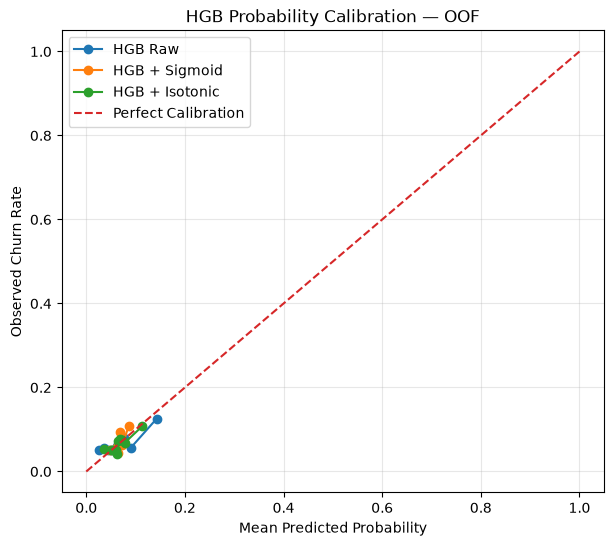

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.plot(
    raw_hgb_calibration_table["Mean Predicted Probability"],
    raw_hgb_calibration_table["Observed Churn Rate"],
    marker="o",
    label="HGB Raw",
)

plt.plot(
    sigmoid_hgb_calibration_table["Mean Predicted Probability"],
    sigmoid_hgb_calibration_table["Observed Churn Rate"],
    marker="o",
    label="HGB + Sigmoid",
)

plt.plot(
    isotonic_hgb_calibration_table["Mean Predicted Probability"],
    isotonic_hgb_calibration_table["Observed Churn Rate"],
    marker="o",
    label="HGB + Isotonic",
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration",
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Churn Rate")
plt.title("HGB Probability Calibration — OOF")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [60]:
final_calibrated_hgb = build_calibrated_model(
    estimator=hist_gradient_boosting_search.best_estimator_,
    method="sigmoid",
    cv=5,
)

final_calibrated_hgb.fit(
    X_train,
    y_train,
)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",Pipeline(step...m_state=42))])
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary <n_jobs>` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
Name,Type,Value
"calibrated_classifiers_ calibrated_classifiers_: list (len() equal to cv or 1 if `ensemble=False`)The list of classifier and calibrator pairs.- When `ensemble=True`, `n_cv` fitted `estimator` and calibrator pairs. `n_cv` is the number of cross-validation folds.- When `ensemble=False`, the `estimator`, fitted on all the data, and fitted calibrator... versionchanged:: 0.24 Single calibrated classifier case when `ensemble=False`.",list,"[<sklearn.cali...001D3F15ED550>, <sk

In [61]:
calibrated_hgb_test_proba = final_calibrated_hgb.predict_proba(
    X_test
)[:, 1]

In [62]:
final_calibrated_hgb_calibration = evaluate_calibration(
    y_true=y_test,
    y_proba=calibrated_hgb_test_proba,
)

final_calibrated_hgb_calibration["brier_score"]

0.06058130822371074

In [63]:
from src.modeling.evaluation import evaluate_test_predictions

In [64]:
final_calibrated_hgb_test_metrics = evaluate_test_predictions(
    y_true=y_test,
    y_proba=calibrated_hgb_test_proba,
    threshold=0.05,
)

final_calibrated_hgb_test_metrics

Threshold               0.050000
PR-AUC                  0.086978
ROC-AUC                 0.578495
Precision               0.067967
Recall                  0.981818
F1                      0.127134
Customers Flagged    1589.000000
Coverage                0.939681
dtype: float64

In [65]:
import src.modeling.thresholds as thresholds

reload(thresholds)

from src.modeling.thresholds import evaluate_thresholds
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
import numpy as np

In [66]:
calibrated_threshold_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

In [67]:
calibrated_hgb_oof_proba = np.zeros(len(y_train))

for train_idx, valid_idx in calibrated_threshold_cv.split(X_train, y_train):
    fold_model = clone(final_calibrated_hgb)

    fold_model.fit(
        X_train.iloc[train_idx],
        y_train.iloc[train_idx],
    )

    calibrated_hgb_oof_proba[valid_idx] = (
        fold_model.predict_proba(
            X_train.iloc[valid_idx]
        )[:, 1]
    )

In [68]:
calibrated_threshold_results = evaluate_thresholds(
    y_true=y_train,
    y_proba=calibrated_hgb_oof_proba,
)

In [69]:
calibrated_threshold_results.sort_values(
    "F1",
    ascending=False,
).head(10)

,Threshold,Precision,Recall,F1,Coverage,Customers Flagged
6,0.07,0.087042,0.302961,0.135231,0.225969,1528
5,0.06,0.070772,0.806378,0.130123,0.739722,5002
7,0.08,0.123318,0.125285,0.124294,0.065957,446
4,0.05,0.065636,0.947608,0.122768,0.937297,6338
1,0.02,0.064922,1.000000,0.121928,1.000000,6762
0,0.01,0.064922,1.000000,0.121928,1.000000,6762
2,0.03,0.064922,1.000000,0.121928,1.000000,6762
3,0.04,0.064578,0.990888,0.121254,0.996155,6736
8,0.09,0.090323,0.031891,0.047138,0.022922,155
9,0.10,0.065789,0.011390,0.019417,0.011239,76


In [70]:
calibrated_threshold_results[
    [
        "Threshold",
        "Precision",
        "Recall",
        "F1",
        "Coverage",
        "Customers Flagged",
    ]
].sort_values(
    "Threshold"
)

,Threshold,Precision,Recall,F1,Coverage,Customers Flagged
0,0.01,0.064922,1.000000,0.121928,1.000000,6762
1,0.02,0.064922,1.000000,0.121928,1.000000,6762
2,0.03,0.064922,1.000000,0.121928,1.000000,6762
3,0.04,0.064578,0.990888,0.121254,0.996155,6736
4,0.05,0.065636,0.947608,0.122768,0.937297,6338
5,0.06,0.070772,0.806378,0.130123,0.739722,5002
6,0.07,0.087042,0.302961,0.135231,0.225969,1528
7,0.08,0.123318,0.125285,0.124294,0.065957,446
8,0.09,0.090323,0.031891,0.047138,0.022922,155
9,0.10,0.065789,0.011390,0.019417,0.011239,76


In [71]:
final_calibrated_hgb_test_metrics_007 = evaluate_test_predictions(
    y_true=y_test,
    y_proba=calibrated_hgb_test_proba,
    threshold=0.07,
)

final_calibrated_hgb_test_metrics_007

Threshold              0.070000
PR-AUC                 0.086978
ROC-AUC                0.578495
Precision              0.085847
Recall                 0.336364
F1                     0.136784
Customers Flagged    431.000000
Coverage               0.254879
dtype: float64

In [72]:
from sklearn.metrics import confusion_matrix

calibrated_hgb_cm_007 = confusion_matrix(
    y_test,
    (calibrated_hgb_test_proba >= 0.07).astype(int),
)

calibrated_hgb_cm_007

array([[1187,  394],
       [  73,   37]])

In [73]:
pd.Series(calibrated_hgb_test_proba).describe()

count    1691.000000
mean        0.065049
std         0.010696
min         0.041706
25%         0.058307
50%         0.064568
75%         0.070318
max         0.122173
dtype: float64

In [74]:
from src.explainability.shap_analysis import (
    get_transformed_feature_names,
    transform_features,
)

In [75]:
final_calibrated_hgb

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",Pipeline(step...m_state=42))])
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary <n_jobs>` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
Name,Type,Value
"calibrated_classifiers_ calibrated_classifiers_: list (len() equal to cv or 1 if `ensemble=False`)The list of classifier and calibrator pairs.- When `ensemble=True`, `n_cv` fitted `estimator` and calibrator pairs. `n_cv` is the number of cross-validation folds.- When `ensemble=False`, the `estimator`, fitted on all the data, and fitted calibrator... versionchanged:: 0.24 Single calibrated classifier case when `ensemble=False`.",list,"[<sklearn.cali...001D3F15ED550>, <sk

In [76]:
final_calibrated_hgb.estimator

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int8](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['CRM_PID_Value_Segment','EffectiveSegment','Active_subscribers',..., 'AvgMobileRevenue','AvgFIXRevenue','ARPU']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'d

In [77]:
tuned_hgb_pipeline = final_calibrated_hgb.estimator

In [78]:
shap_feature_names = get_transformed_feature_names(
    tuned_hgb_pipeline.named_steps["preprocessor"]
)

len(shap_feature_names), shap_feature_names

(23,
 array(['numeric__Active_subscribers', 'numeric__Not_Active_subscribers',
        'numeric__Suspended_subscribers', 'numeric__Total_SUBs',
        'numeric__AvgMobileRevenue', 'numeric__AvgFIXRevenue',
        'numeric__ARPU', 'categorical__CRM_PID_Value_Segment_Bronze',
        'categorical__CRM_PID_Value_Segment_Gold',
        'categorical__CRM_PID_Value_Segment_Iron',
        'categorical__CRM_PID_Value_Segment_Lead',
        'categorical__CRM_PID_Value_Segment_Missing',
        'categorical__CRM_PID_Value_Segment_Platinum',
        'categorical__CRM_PID_Value_Segment_SE',
        'categorical__CRM_PID_Value_Segment_SME',
        'categorical__CRM_PID_Value_Segment_Silver',
        'categorical__CRM_PID_Value_Segment_Sliver',
        'categorical__EffectiveSegment_LE',
        'categorical__EffectiveSegment_Other',
        'categorical__EffectiveSegment_SE',
        'categorical__EffectiveSegment_SME',
        'categorical__EffectiveSegment_SOHO',
        'categorical__Effectiv

In [79]:
shap_sample = X_train.sample(
    n=min(1000, len(X_train)),
    random_state=42,
)

In [80]:
from src.explainability.shap_analysis import calculate_shap_values

shap_values = calculate_shap_values(
    model=tuned_hgb_pipeline,
    X=shap_sample,
)

In [81]:
type(shap_values)

numpy.ndarray

In [82]:
np.asarray(shap_values).shape

(1000, 23)

In [83]:
len(shap_feature_names)

23

In [84]:
shap_importance = pd.DataFrame({
    "Feature": shap_feature_names,
    "Mean Absolute SHAP": np.abs(shap_values).mean(axis=0),
}).sort_values(
    "Mean Absolute SHAP",
    ascending=False,
).reset_index(drop=True)

In [85]:
shap_importance.head(15)

,Feature,Mean Absolute SHAP
0,numeric__AvgMobileRevenue,0.268375
1,numeric__ARPU,0.179074
2,numeric__Active_subscribers,0.097232
3,numeric__Total_SUBs,0.065972
4,numeric__Not_Active_subscribers,0.054174
5,categorical__CRM_PID_Value_Segment_Bronze,0.012929
6,categorical__EffectiveSegment_SOHO,0.009159
7,categorical__CRM_PID_Value_Segment_Gold,0.008357
8,categorical__CRM_PID_Value_Segment_Silver,0.008331
9,categorical__CRM_PID_Value_Segment_Platinum,0.008104


In [86]:
shap_importance["Relative Importance"] = (
    shap_importance["Mean Absolute SHAP"]
    / shap_importance["Mean Absolute SHAP"].sum()
)

In [87]:
shap_importance.head(15)

,Feature,Mean Absolute SHAP,Relative Importance
0,numeric__AvgMobileRevenue,0.268375,0.368576
1,numeric__ARPU,0.179074,0.245934
2,numeric__Active_subscribers,0.097232,0.133534
3,numeric__Total_SUBs,0.065972,0.090603
4,numeric__Not_Active_subscribers,0.054174,0.074401
5,categorical__CRM_PID_Value_Segment_Bronze,0.012929,0.017756
6,categorical__EffectiveSegment_SOHO,0.009159,0.012578
7,categorical__CRM_PID_Value_Segment_Gold,0.008357,0.011478
8,categorical__CRM_PID_Value_Segment_Silver,0.008331,0.011442
9,categorical__CRM_PID_Value_Segment_Platinum,0.008104,0.011130


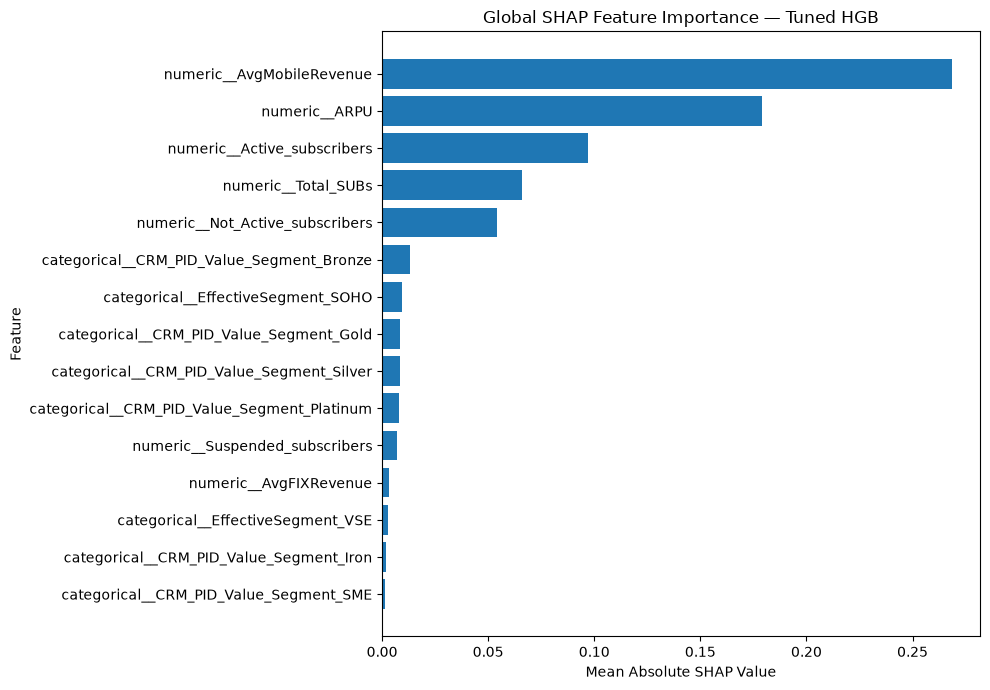

In [88]:
import matplotlib.pyplot as plt

top_shap = shap_importance.head(15).sort_values(
    "Mean Absolute SHAP"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_shap["Feature"],
    top_shap["Mean Absolute SHAP"],
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("Global SHAP Feature Importance — Tuned HGB")

plt.tight_layout()
plt.show()

In [89]:
X_shap_transformed = tuned_hgb_pipeline.named_steps[
    "preprocessor"
].transform(shap_sample)

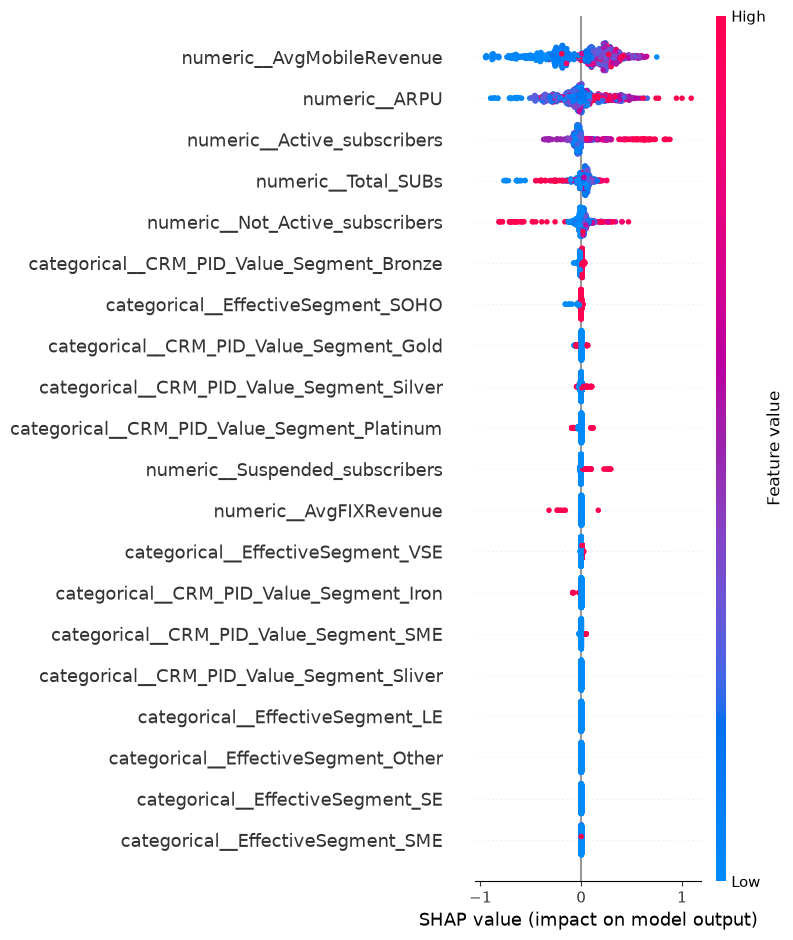

In [90]:
import shap
shap.summary_plot(
    shap_values,
    X_shap_transformed,
    feature_names=shap_feature_names,
    show=False,
)

plt.tight_layout()
plt.show()

In [91]:
shap_importance.head(15)

,Feature,Mean Absolute SHAP,Relative Importance
0,numeric__AvgMobileRevenue,0.268375,0.368576
1,numeric__ARPU,0.179074,0.245934
2,numeric__Active_subscribers,0.097232,0.133534
3,numeric__Total_SUBs,0.065972,0.090603
4,numeric__Not_Active_subscribers,0.054174,0.074401
5,categorical__CRM_PID_Value_Segment_Bronze,0.012929,0.017756
6,categorical__EffectiveSegment_SOHO,0.009159,0.012578
7,categorical__CRM_PID_Value_Segment_Gold,0.008357,0.011478
8,categorical__CRM_PID_Value_Segment_Silver,0.008331,0.011442
9,categorical__CRM_PID_Value_Segment_Platinum,0.008104,0.011130


In [92]:
import src.explainability.shap_analysis as shap_analysis

reload(shap_analysis)
from src.explainability.shap_analysis import (
    aggregate_shap_importance,
)

In [93]:
business_shap_importance = aggregate_shap_importance(
    shap_values=shap_values,
    feature_names=shap_feature_names,
)

In [94]:
business_shap_importance

,Feature,Mean Absolute SHAP,Relative Importance
0,AvgMobileRevenue,0.268375,0.368576
1,ARPU,0.179074,0.245934
2,Active_subscribers,0.097232,0.133534
3,Total_SUBs,0.065972,0.090603
4,Not_Active_subscribers,0.054174,0.074401
5,CRM_PID_Value_Segment,0.041265,0.056672
6,EffectiveSegment,0.011917,0.016366
7,Suspended_subscribers,0.007043,0.009673
8,AvgFIXRevenue,0.003087,0.004240


In [95]:
X_shap_numeric = shap_sample[
    [
        "AvgMobileRevenue",
        "ARPU",
        "Active_subscribers",
        "Total_SUBs",
        "Not_Active_subscribers",
    ]
].copy()

In [96]:
numeric_shap_results = pd.DataFrame({
    "Feature": shap_feature_names,
    "Mean SHAP": shap_values.mean(axis=0),
    "Mean Absolute SHAP": np.abs(shap_values).mean(axis=0),
})

In [97]:
numeric_shap_results[
    numeric_shap_results["Feature"].isin(
        [
            "numeric__AvgMobileRevenue",
            "numeric__ARPU",
            "numeric__Active_subscribers",
            "numeric__Total_SUBs",
            "numeric__Not_Active_subscribers",
        ]
    )
].sort_values(
    "Mean Absolute SHAP",
    ascending=False,
)

,Feature,Mean SHAP,Mean Absolute SHAP
4,numeric__AvgMobileRevenue,0.015278,0.268375
6,numeric__ARPU,-0.007408,0.179074
0,numeric__Active_subscribers,0.012135,0.097232
3,numeric__Total_SUBs,0.009549,0.065972
1,numeric__Not_Active_subscribers,-0.003758,0.054174


In [98]:
directionality_rows = []

for feature in [
    "AvgMobileRevenue",
    "ARPU",
    "Active_subscribers",
    "Total_SUBs",
    "Not_Active_subscribers",
]:
    shap_feature = f"numeric__{feature}"

    feature_index = list(shap_feature_names).index(
        shap_feature
    )

    feature_values = shap_sample[feature].to_numpy()
    feature_shap = shap_values[:, feature_index]

    correlation = np.corrcoef(
        feature_values,
        feature_shap,
    )[0, 1]

    directionality_rows.append(
        {
            "Feature": feature,
            "Value-SHAP Correlation": correlation,
            "Mean SHAP": feature_shap.mean(),
            "Mean Absolute SHAP": np.abs(feature_shap).mean(),
        }
    )

directionality = pd.DataFrame(
    directionality_rows
).sort_values(
    "Mean Absolute SHAP",
    ascending=False,
)

directionality

,Feature,Value-SHAP Correlation,Mean SHAP,Mean Absolute SHAP
0,AvgMobileRevenue,0.540129,0.015278,0.268375
1,ARPU,0.196946,-0.007408,0.179074
2,Active_subscribers,0.754915,0.012135,0.097232
3,Total_SUBs,-0.143984,0.009549,0.065972
4,Not_Active_subscribers,-0.114493,-0.003758,0.054174


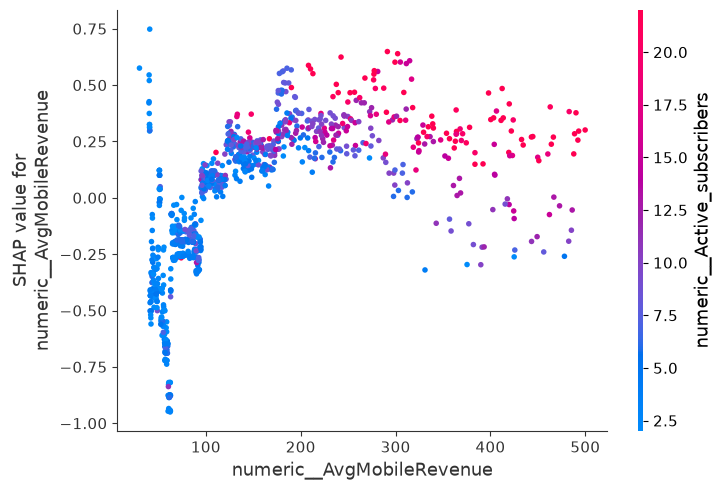

In [99]:
feature_index = list(shap_feature_names).index(
    "numeric__AvgMobileRevenue"
)

shap.dependence_plot(
    feature_index,
    shap_values,
    X_shap_transformed,
    feature_names=shap_feature_names,
    show=False,
)

plt.tight_layout()
plt.show()

In [100]:
from src.explainability.segment_analysis import (
    calculate_segment_shap_summary,
    calculate_segment_feature_importance
)

effective_segment_summary = calculate_segment_shap_summary(
    shap_values=shap_values,
    segments=shap_sample["EffectiveSegment"],
    feature_names=shap_feature_names,
)

effective_segment_summary

,EffectiveSegment,Mean SHAP,Mean Absolute SHAP,Customers
0,SE,0.010910,0.059417,4
1,SME,0.012212,0.047023,35
2,VSE,0.013445,0.040914,226
3,SOHO,-0.004223,0.027939,731
4,Other,0.005666,0.026221,4


In [101]:
effective_segment_importance = calculate_segment_feature_importance(
    shap_values=shap_values,
    segments=shap_sample["EffectiveSegment"],
    feature_names=shap_feature_names,
)

effective_segment_importance.head(20)

,EffectiveSegment,Feature,Mean SHAP,Mean Absolute SHAP,Customers
0,Other,numeric__AvgMobileRevenue,0.041096,0.216350,4
1,Other,numeric__Active_subscribers,0.109185,0.160814,4
2,Other,numeric__Total_SUBs,0.059787,0.064215,4
3,Other,numeric__ARPU,-0.016430,0.055919,4
4,Other,numeric__Not_Active_subscribers,0.001400,0.028757,4
5,Other,categorical__EffectiveSegment_SOHO,-0.021994,0.021994,4
6,Other,categorical__CRM_PID_Value_Segment_Bronze,-0.017274,0.017274,4
7,Other,categorical__CRM_PID_Value_Segment_Gold,-0.008632,0.011689,4
8,Other,categorical__CRM_PID_Value_Segment_Platinum,-0.007507,0.010513,4
9,Other,categorical__CRM_PID_Value_Segment_Iron,-0.004623,0.005561,4


In [102]:
dominant_features = [
    "numeric__AvgMobileRevenue",
    "numeric__ARPU",
    "numeric__Active_subscribers",
    "numeric__Total_SUBs",
    "numeric__Not_Active_subscribers",
]

effective_segment_numeric = effective_segment_importance[
    effective_segment_importance["Feature"].isin(dominant_features)
].copy()

effective_segment_numeric

,EffectiveSegment,Feature,Mean SHAP,Mean Absolute SHAP,Customers
0,Other,numeric__AvgMobileRevenue,0.041096,0.216350,4
1,Other,numeric__Active_subscribers,0.109185,0.160814,4
2,Other,numeric__Total_SUBs,0.059787,0.064215,4
3,Other,numeric__ARPU,-0.016430,0.055919,4
4,Other,numeric__Not_Active_subscribers,0.001400,0.028757,4
23,SE,numeric__Active_subscribers,0.324403,0.399165,4
24,SE,numeric__AvgMobileRevenue,0.258400,0.258400,4
25,SE,numeric__ARPU,0.012920,0.235806,4
26,SE,numeric__Not_Active_subscribers,-0.216371,0.216371,4
27,SE,numeric__Total_SUBs,-0.059669,0.165197,4


In [103]:
effective_segment_numeric["Feature"] = (
    effective_segment_numeric["Feature"]
    .str.replace("numeric__", "", regex=False)
)

effective_segment_numeric

,EffectiveSegment,Feature,Mean SHAP,Mean Absolute SHAP,Customers
0,Other,AvgMobileRevenue,0.041096,0.216350,4
1,Other,Active_subscribers,0.109185,0.160814,4
2,Other,Total_SUBs,0.059787,0.064215,4
3,Other,ARPU,-0.016430,0.055919,4
4,Other,Not_Active_subscribers,0.001400,0.028757,4
23,SE,Active_subscribers,0.324403,0.399165,4
24,SE,AvgMobileRevenue,0.258400,0.258400,4
25,SE,ARPU,0.012920,0.235806,4
26,SE,Not_Active_subscribers,-0.216371,0.216371,4
27,SE,Total_SUBs,-0.059669,0.165197,4


In [104]:
crm_segment_summary = calculate_segment_shap_summary(
    shap_values=shap_values,
    segments=shap_sample["CRM_PID_Value_Segment"],
    feature_names=shap_feature_names,
)

crm_segment_summary

,EffectiveSegment,Mean SHAP,Mean Absolute SHAP,Customers
0,SE,0.010910,0.059417,4
1,SME,0.012212,0.047023,35
2,Platinum,0.018752,0.045160,75
3,Lead,-0.037194,0.044359,1
4,Iron,-0.019846,0.038342,30
5,Gold,0.013317,0.038041,181
6,Bronze,-0.010616,0.027532,427
7,Silver,0.005347,0.026544,246
8,NaN,0.007968,0.021802,1


In [105]:
crm_segment_summary = calculate_segment_shap_summary(
    shap_values=shap_values,
    segments=shap_sample["CRM_PID_Value_Segment"],
    feature_names=shap_feature_names,
)

crm_segment_summary

,EffectiveSegment,Mean SHAP,Mean Absolute SHAP,Customers
0,SE,0.010910,0.059417,4
1,SME,0.012212,0.047023,35
2,Platinum,0.018752,0.045160,75
3,Lead,-0.037194,0.044359,1
4,Iron,-0.019846,0.038342,30
5,Gold,0.013317,0.038041,181
6,Bronze,-0.010616,0.027532,427
7,Silver,0.005347,0.026544,246
8,NaN,0.007968,0.021802,1


In [106]:
test_business_data = df.loc[X_test.index, [
    "PID",
    "TotalRevenue",
    "CHURN",
]].copy()

In [107]:
assert len(test_business_data) == len(calibrated_hgb_test_proba)
assert test_business_data.index.equals(X_test.index)

In [108]:
from src.business.risk import build_risk_table

risk_table = build_risk_table(
    data=test_business_data,
    churn_probability=calibrated_hgb_test_proba,
    threshold=0.07,
)

risk_table.head()

,PID,TotalRevenue,CHURN,Churn Probability,Revenue at Risk,Retention Flag
0,123759242,40.17,No,0.052353,2.103025,False
1,126145737,40.17,No,0.079356,3.187747,True
2,123506355,40.17,No,0.049094,1.972121,False
3,112595585,40.17,No,0.072625,2.917348,True
4,115097935,40.17,No,0.065515,2.631741,False


In [109]:
risk_table[
    [
        "PID",
        "TotalRevenue",
        "Churn Probability",
        "Revenue at Risk",
        "Retention Flag",
        "CHURN",
    ]
].head(20)

,PID,TotalRevenue,Churn Probability,Revenue at Risk,Retention Flag,CHURN
0,123759242,40.17,0.052353,2.103025,False,No
1,126145737,40.17,0.079356,3.187747,True,No
2,123506355,40.17,0.049094,1.972121,False,No
3,112595585,40.17,0.072625,2.917348,True,No
4,115097935,40.17,0.065515,2.631741,False,No
5,108684074,40.17,0.055896,2.245329,False,No
6,112504678,40.33,0.069283,2.794198,False,Yes
7,833121152,40.33,0.048026,1.936885,False,No
8,123654309,40.33,0.065949,2.659737,False,No
9,123688980,40.33,0.061909,2.496795,False,No


In [110]:
risk_summary = pd.Series(
    {
        "Observations": len(risk_table),
        "Flagged Observations": int(
            risk_table["Retention Flag"].sum()
        ),
        "Flagged Coverage": risk_table["Retention Flag"].mean(),
        "Total Revenue": risk_table["TotalRevenue"].sum(),
        "Total Revenue at Risk": risk_table["Revenue at Risk"].sum(),
        "Flagged Revenue": risk_table.loc[
            risk_table["Retention Flag"],
            "TotalRevenue",
        ].sum(),
        "Flagged Revenue at Risk": risk_table.loc[
            risk_table["Retention Flag"],
            "Revenue at Risk",
        ].sum(),
    }
)

risk_summary

Observations                 1691.000000
Flagged Observations          431.000000
Flagged Coverage                0.254879
Total Revenue              116713.130000
Total Revenue at Risk        7599.402334
Flagged Revenue             29914.840000
Flagged Revenue at Risk      2356.269191
dtype: float64

In [111]:
top_revenue_risk = (
    risk_table[
        [
            "PID",
            "TotalRevenue",
            "Churn Probability",
            "Revenue at Risk",
            "Retention Flag",
            "CHURN",
        ]
    ]
    .sort_values(
        "Revenue at Risk",
        ascending=False,
    )
    .head(20)
)

top_revenue_risk

,PID,TotalRevenue,Churn Probability,Revenue at Risk,Retention Flag,CHURN
1631,112659461,94.83,0.110313,10.461023,True,No
1652,115823080,95.67,0.098184,9.393243,True,No
1394,176159045,86.83,0.100897,8.760861,True,No
1669,126016977,96.17,0.090368,8.690656,True,No
1679,20361531,96.50,0.089678,8.653881,True,No
1525,112506259,91.33,0.094296,8.612077,True,No
1655,825315360,95.83,0.089507,8.577432,True,No
1507,202046728,90.50,0.092616,8.381745,True,No
1129,123757750,78.33,0.106220,8.320185,True,No
1572,123739040,92.83,0.088689,8.233005,True,No


In [112]:
from src.business.risk import assign_risk_band

risk_table["Risk Band"] = assign_risk_band(
    risk_table["Churn Probability"]
)

In [113]:
risk_table[
    [
        "PID",
        "Churn Probability",
        "Risk Band",
        "TotalRevenue",
        "Revenue at Risk",
        "Retention Flag",
        "CHURN",
    ]
].head(20)

,PID,Churn Probability,Risk Band,TotalRevenue,Revenue at Risk,Retention Flag,CHURN
0,123759242,0.052353,Moderate,40.17,2.103025,False,No
1,126145737,0.079356,High,40.17,3.187747,True,No
2,123506355,0.049094,Low,40.17,1.972121,False,No
3,112595585,0.072625,High,40.17,2.917348,True,No
4,115097935,0.065515,Moderate,40.17,2.631741,False,No
5,108684074,0.055896,Moderate,40.17,2.245329,False,No
6,112504678,0.069283,Moderate,40.33,2.794198,False,Yes
7,833121152,0.048026,Low,40.33,1.936885,False,No
8,123654309,0.065949,Moderate,40.33,2.659737,False,No
9,123688980,0.061909,Moderate,40.33,2.496795,False,No


In [115]:
risk_table["Observed Churn"] = (
    risk_table["CHURN"] == "Yes"
).astype(int)

In [117]:
risk_band_summary = (
    risk_table
    .groupby("Risk Band", observed=True)
    .agg(
        Observations=("PID", "size"),
        TotalRevenue=("TotalRevenue", "sum"),
        RevenueAtRisk=("Revenue at Risk", "sum"),
        MeanChurnProbability=("Churn Probability", "mean"),
        ObservedChurnRate=("Observed Churn", "mean"),
        FlaggedObservations=("Retention Flag", "sum"),
    )
    .reset_index()
)

risk_band_summary["Coverage"] = (
    risk_band_summary["Observations"]
    / len(risk_table)
)

risk_band_summary["RevenueShare"] = (
    risk_band_summary["TotalRevenue"]
    / risk_table["TotalRevenue"].sum()
)

risk_band_summary["RevenueAtRiskShare"] = (
    risk_band_summary["RevenueAtRisk"]
    / risk_table["Revenue at Risk"].sum()
)

risk_band_summary

,Risk Band,Observations,TotalRevenue,RevenueAtRisk,MeanChurnProbability,ObservedChurnRate,FlaggedObservations,Coverage,RevenueShare,RevenueAtRiskShare
0,High,431,29914.84,2356.269191,0.078769,0.032483,431,0.254879,0.256311,0.310060
1,Low,102,6838.87,321.921873,0.047096,0.029412,0,0.060319,0.058596,0.042361
2,Moderate,1158,79959.42,4921.211270,0.061524,0.047496,0,0.684802,0.685094,0.647579


In [118]:
risk_table["Churn Probability"].describe()

count    1691.000000
mean        0.065049
std         0.010696
min         0.041706
25%         0.058307
50%         0.064568
75%         0.070318
max         0.122173
Name: Churn Probability, dtype: float64

In [119]:
risk_table[
    [
        "Churn Probability",
        "Risk Band",
    ]
].groupby("Risk Band", observed=True)["Churn Probability"].agg(
    ["min", "max", "mean", "count"]
)

,min,max,mean,count
Risk Band,,,,
High,0.070067,0.122173,0.078769,431
Low,0.041706,0.049960,0.047096,102
Moderate,0.050014,0.069981,0.061524,1158


In [120]:
risk_table["Revenue at Risk"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

count    1691.000000
mean        4.494029
std         1.308041
min         1.904627
25%         3.498914
50%         4.391024
75%         5.368006
90%         6.249993
95%         6.760903
99%         7.919977
max        10.461023
Name: Revenue at Risk, dtype: float64

In [121]:
risk_table["Revenue at Risk"].sort_values(ascending=False).head(20)

1631    10.461023
1652     9.393243
1394     8.760861
1669     8.690656
1679     8.653881
1525     8.612077
1655     8.577432
1507     8.381745
1129     8.320185
1572     8.233005
1634     8.229564
1302     8.228719
1481     8.187183
1228     8.138044
1291     8.088579
1378     8.028013
1682     7.979934
1522     7.913315
1538     7.897935
1364     7.823297
Name: Revenue at Risk, dtype: float64

In [122]:
priority_table = risk_table.copy()

priority_table["Priority Rank"] = (
    priority_table["Revenue at Risk"]
    .rank(method="first", ascending=False)
    .astype(int)
)

priority_table = priority_table.sort_values(
    "Revenue at Risk",
    ascending=False
)

In [123]:
priority_table[
    [
        "Priority Rank",
        "PID",
        "Churn Probability",
        "Risk Band",
        "TotalRevenue",
        "Revenue at Risk",
        "Retention Flag",
        "CHURN",
    ]
].head(20)

,Priority Rank,PID,Churn Probability,Risk Band,TotalRevenue,Revenue at Risk,Retention Flag,CHURN
1631,1,112659461,0.110313,High,94.83,10.461023,True,No
1652,2,115823080,0.098184,High,95.67,9.393243,True,No
1394,3,176159045,0.100897,High,86.83,8.760861,True,No
1669,4,126016977,0.090368,High,96.17,8.690656,True,No
1679,5,20361531,0.089678,High,96.50,8.653881,True,No
1525,6,112506259,0.094296,High,91.33,8.612077,True,No
1655,7,825315360,0.089507,High,95.83,8.577432,True,No
1507,8,202046728,0.092616,High,90.50,8.381745,True,No
1129,9,123757750,0.106220,High,78.33,8.320185,True,No
1572,10,123739040,0.088689,High,92.83,8.233005,True,No


In [124]:
retention_priority = priority_table[
    [
        "Priority Rank",
        "PID",
        "Churn Probability",
        "Risk Band",
        "TotalRevenue",
        "Revenue at Risk",
        "Retention Flag",
        "CHURN",
    ]
].copy()

In [126]:
retention_priority.head(20)

,Priority Rank,PID,Churn Probability,Risk Band,TotalRevenue,Revenue at Risk,Retention Flag,CHURN
1631,1,112659461,0.110313,High,94.83,10.461023,True,No
1652,2,115823080,0.098184,High,95.67,9.393243,True,No
1394,3,176159045,0.100897,High,86.83,8.760861,True,No
1669,4,126016977,0.090368,High,96.17,8.690656,True,No
1679,5,20361531,0.089678,High,96.50,8.653881,True,No
1525,6,112506259,0.094296,High,91.33,8.612077,True,No
1655,7,825315360,0.089507,High,95.83,8.577432,True,No
1507,8,202046728,0.092616,High,90.50,8.381745,True,No
1129,9,123757750,0.106220,High,78.33,8.320185,True,No
1572,10,123739040,0.088689,High,92.83,8.233005,True,No


In [128]:
import src.business.risk as risk
reload(risk)
from src.business.risk import assign_priority_tier

risk_table["Priority Tier"] = assign_priority_tier(
    risk_table["Revenue at Risk"]
)

In [129]:
risk_table["Priority Rank"] = (
    risk_table["Revenue at Risk"]
    .rank(method="first", ascending=False)
    .astype(int)
)

retention_priority = risk_table.sort_values(
    "Revenue at Risk",
    ascending=False,
)

In [130]:
risk_table.groupby("Priority Tier", observed=True).agg(
    Observations=("PID", "size"),
    RevenueAtRisk=("Revenue at Risk", "sum"),
    MeanRevenueAtRisk=("Revenue at Risk", "mean"),
    MeanChurnProbability=("Churn Probability", "mean"),
)

,Observations,RevenueAtRisk,MeanRevenueAtRisk,MeanChurnProbability
Priority Tier,,,,
Critical,169,1176.549665,6.961832,0.080064
Priority,254,1468.391309,5.781068,0.069468
Standard,1268,4954.461360,3.907304,0.062162


In [133]:
import src.business.risk as risk
reload(risk)
from src.business.risk import (assign_retention_action, assign_retention_urgency)

In [134]:
risk_table["Retention Action"] = assign_retention_action(
    risk_table["Risk Band"],
    risk_table["Priority Tier"],
)

In [135]:
risk_table["Retention Urgency"] = assign_retention_urgency(
    risk_table["Risk Band"],
    risk_table["Priority Tier"],
)

In [136]:
risk_table[
    [
        "Risk Band",
        "Priority Tier",
        "Retention Action",
        "Retention Urgency",
    ]
].value_counts().sort_index()

Risk Band  Priority Tier  Retention Action                   Retention Urgency
High       Critical       Highest-priority retention review  Very High            139
           Priority       Proactive retention intervention   Very High             89
           Standard       Targeted retention review          High                 203
Low        Standard       Normal lifecycle management        Low                  102
Moderate   Critical       Prioritized retention review       High                  30
           Priority       Proactive retention review         High                 165
           Standard       Add to monitoring workflow         Medium               963
Name: count, dtype: int64

In [137]:
risk_table[
    [
        "PID",
        "Churn Probability",
        "Risk Band",
        "TotalRevenue",
        "Revenue at Risk",
        "Priority Tier",
        "Retention Action",
        "Retention Urgency",
        "CHURN",
    ]
].sort_values(
    "Revenue at Risk",
    ascending=False,
).head(20)

,PID,Churn Probability,Risk Band,TotalRevenue,Revenue at Risk,Priority Tier,Retention Action,Retention Urgency,CHURN
1631,112659461,0.110313,High,94.83,10.461023,Critical,Highest-priority retention review,Very High,No
1652,115823080,0.098184,High,95.67,9.393243,Critical,Highest-priority retention review,Very High,No
1394,176159045,0.100897,High,86.83,8.760861,Critical,Highest-priority retention review,Very High,No
1669,126016977,0.090368,High,96.17,8.690656,Critical,Highest-priority retention review,Very High,No
1679,20361531,0.089678,High,96.50,8.653881,Critical,Highest-priority retention review,Very High,No
1525,112506259,0.094296,High,91.33,8.612077,Critical,Highest-priority retention review,Very High,No
1655,825315360,0.089507,High,95.83,8.577432,Critical,Highest-priority retention review,Very High,No
1507,202046728,0.092616,High,90.50,8.381745,Critical,Highest-priority retention review,Very High,No
1129,123757750,0.106220,High,78.33,8.320185,Critical,Highest-priority retention review,Very High,No
1572,123739040,0.088689,High,92.83,8.233005,Critical,Highest-priority retention review,Very High,No


In [144]:
from pathlib import Path
import mlflow

PROJECT_ROOT = Path.cwd().parent
MLFLOW_DB = PROJECT_ROOT / "mlflow.db"

mlflow.set_tracking_uri(f"sqlite:///{MLFLOW_DB}")
mlflow.set_experiment("telecom-churn")

print("Project root:", PROJECT_ROOT)
print("MLflow DB:", MLFLOW_DB)
print("Tracking URI:", mlflow.get_tracking_uri())

2026/09/29 15:39:13 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/29 15:39:13 INFO mlflow.store.db.utils: Updating database tables
2026/09/29 15:39:14 INFO mlflow.tracking.fluent: Experiment with name 'telecom-churn' does not exist. Creating a new experiment.


Project root: c:\Users\yashv\OneDrive\Desktop\telecom-churn-platform
MLflow DB: c:\Users\yashv\OneDrive\Desktop\telecom-churn-platform\mlflow.db
Tracking URI: sqlite:///c:\Users\yashv\OneDrive\Desktop\telecom-churn-platform\mlflow.db


In [145]:
mlflow.get_tracking_uri()

'sqlite:///c:\\Users\\yashv\\OneDrive\\Desktop\\telecom-churn-platform\\mlflow.db'

In [146]:
with mlflow.start_run(run_name="final-calibrated-hgb"):
    mlflow.set_tag(
        "model_type",
        "HistGradientBoostingClassifier",
    )

    mlflow.set_tag(
        "calibration",
        "sigmoid",
    )

    mlflow.set_tag(
        "purpose",
        "candidate_model",
    )

    mlflow.log_param("threshold", 0.07)
    mlflow.log_param("random_state", 42)

In [147]:
runs = mlflow.search_runs(
    experiment_names=["telecom-churn"]
)

runs[
    [
        "run_id",
        "status",
        "tags.model_type",
        "tags.calibration",
        "params.threshold",
        "params.random_state",
    ]
]

,run_id,status,tags.model_type,tags.calibration,params.threshold,params.random_state
0,0a3f8a918bb24e0a8bd4effeb44b9643,FINISHED,HistGradientBoostingClassifier,sigmoid,0.07,42


In [149]:
import src.tracking.mlflow_tracking as mlflow_tracking
reload(mlflow_tracking)

<module 'src.tracking.mlflow_tracking' from 'c:\\Users\\yashv\\OneDrive\\Desktop\\telecom-churn-platform\\src\\tracking\\mlflow_tracking.py'>

In [150]:
from pathlib import Path
import mlflow

from src.tracking.mlflow_tracking import (
    configure_mlflow,
    log_model_parameters,
    log_model_metrics,
)

PROJECT_ROOT = Path.cwd().parent
MLFLOW_DB = PROJECT_ROOT / "mlflow.db"

configure_mlflow(
    experiment_name="telecom-churn",
    tracking_uri=f"sqlite:///{MLFLOW_DB}",
)

with mlflow.start_run(run_name="final-calibrated-hgb-v1"):

    mlflow.set_tag("purpose", "candidate_model")
    mlflow.set_tag("model_type", "HistGradientBoostingClassifier")
    mlflow.set_tag("calibration", "sigmoid")

    log_model_parameters(
        model_type="HistGradientBoostingClassifier",
        calibration="sigmoid",
        calibration_cv=5,
        threshold=0.07,
        random_state=42,
        hyperparameters={
            "max_iter": 300,
            "learning_rate": 0.05,
            "max_leaf_nodes": 15,
            "min_samples_leaf": 20,
            "l2_regularization": 1.0,
        },
    )

    log_model_metrics({
        "test_pr_auc": 0.086978,
        "test_roc_auc": 0.578495,
        "test_precision": 0.085847,
        "test_recall": 0.336364,
        "test_f1": 0.136784,
        "test_brier_score": 0.0605813082,
        "test_coverage": 0.254879,
        "customers_flagged": 431,
    })

In [153]:
runs = mlflow.search_runs(
    experiment_names=["telecom-churn"]
)

runs[
    [
        "run_id",
        "tags.mlflow.runName",
        "status",
        "tags.model_type",
        "tags.calibration",
        "params.threshold",
        "metrics.test_pr_auc",
        "metrics.test_roc_auc",
        "metrics.test_f1",
    ]
].head().head()

,run_id,tags.mlflow.runName,status,tags.model_type,tags.calibration,params.threshold,metrics.test_pr_auc,metrics.test_roc_auc,metrics.test_f1
0,160ee13a40884b27a36b8164e0bc8d1d,final-calibrated-hgb-v1,FINISHED,HistGradientBoostingClassifier,sigmoid,0.07,0.086978,0.578495,0.136784
1,0a3f8a918bb24e0a8bd4effeb44b9643,final-calibrated-hgb,FINISHED,HistGradientBoostingClassifier,sigmoid,0.07,NaN,NaN,NaN


In [154]:
import mlflow

print(mlflow.__version__)

3.16.1


In [156]:
import mlflow
import mlflow.sklearn

trusted_types = [
    "numpy.dtype",
    "sklearn.calibration._CalibratedClassifier",
    "sklearn.calibration._SigmoidCalibration",
    "sklearn.ensemble._hist_gradient_boosting.predictor.TreePredictor",
]

with mlflow.start_run(run_name="final-calibrated-hgb-v1-model") as run:
    mlflow.sklearn.log_model(
        sk_model=final_calibrated_hgb,
        name="final_calibrated_hgb",
        skops_trusted_types=trusted_types,
    )

    model_run_id = run.info.run_id

print("Run ID:", model_run_id)

Run ID: 3b084ccb783f48ee8a51caf29f52b919


In [158]:
run = mlflow.get_run(model_run_id)

print("Run ID:", run.info.run_id)
print("Status:", run.info.status)
print("Artifact URI:", run.info.artifact_uri)
print("Tags:", run.data.tags)

Run ID: 3b084ccb783f48ee8a51caf29f52b919
Status: FINISHED
Artifact URI: file:c:/Users/yashv/OneDrive/Desktop/telecom-churn-platform/notebooks/mlruns/1/3b084ccb783f48ee8a51caf29f52b919/artifacts
Tags: {'mlflow.user': 'yashv', 'mlflow.source.name': '03_model_comparison.ipynb', 'mlflow.source.type': 'NOTEBOOK', 'mlflow.runName': 'final-calibrated-hgb-v1-model'}


In [165]:
models = mlflow.search_logged_models(
    filter_string=f"source_run_id = '{model_run_id}'"
)

models

,artifact_location,creation_timestamp,experiment_id,last_updated_timestamp,metrics,model_id,model_type,name,params,source_run_id,status,status_message,tags
0,file:c:/Users/yashv/OneDrive/Desktop/telecom-c...,1790677508452,1,1790677529177,None,m-68e092eaed1a442b94e25ab7fa33fc89,None,final_calibrated_hgb,{},3b084ccb783f48ee8a51caf29f52b919,READY,None,{'mlflow.source.name': '03_model_comparison.ip...


In [168]:
print(type(models))
print(models)

<class 'pandas.DataFrame'>
                                   artifact_location  creation_timestamp  \
0  file:c:/Users/yashv/OneDrive/Desktop/telecom-c...       1790677508452   

  experiment_id  last_updated_timestamp metrics  \
0             1           1790677529177    None   

                             model_id model_type                  name params  \
0  m-68e092eaed1a442b94e25ab7fa33fc89       None  final_calibrated_hgb     {}   

                      source_run_id status status_message  \
0  3b084ccb783f48ee8a51caf29f52b919  READY           None   

                                                tags  
0  {'mlflow.source.name': '03_model_comparison.ip...  


In [169]:
print(models.shape)
print(models.columns.tolist())

(1, 13)
['artifact_location', 'creation_timestamp', 'experiment_id', 'last_updated_timestamp', 'metrics', 'model_id', 'model_type', 'name', 'params', 'source_run_id', 'status', 'status_message', 'tags']


In [170]:
[column for column in [
    "model_id",
    "name",
    "status",
    "source_run_id",
    "artifact_uri",
] if column in models.columns]

['model_id', 'name', 'status', 'source_run_id']

In [171]:
models[
    [
        "model_id",
        "name",
        "status",
        "source_run_id",
    ]
]

,model_id,name,status,source_run_id
0,m-68e092eaed1a442b94e25ab7fa33fc89,final_calibrated_hgb,READY,3b084ccb783f48ee8a51caf29f52b919


In [172]:
logged_model = models.iloc[0]

print("Model ID:", logged_model["model_id"])
print("Model name:", logged_model["name"])
print("Status:", logged_model["status"])
print("Source run:", logged_model["source_run_id"])

Model ID: m-68e092eaed1a442b94e25ab7fa33fc89
Model name: final_calibrated_hgb
Status: READY
Source run: 3b084ccb783f48ee8a51caf29f52b919


In [173]:
model_info = mlflow.get_logged_model(
    logged_model["model_id"]
)

print(model_info)

LoggedModel(artifact_location='file:c:/Users/yashv/OneDrive/Desktop/telecom-churn-platform/notebooks/mlruns/1/models/m-68e092eaed1a442b94e25ab7fa33fc89/artifacts', creation_timestamp=1790677508452, experiment_id='1', last_updated_timestamp=1790677529177, model_id='m-68e092eaed1a442b94e25ab7fa33fc89', model_type=None, model_uri='models:/m-68e092eaed1a442b94e25ab7fa33fc89', name='final_calibrated_hgb', source_run_id='3b084ccb783f48ee8a51caf29f52b919', status=<LoggedModelStatus.READY: 'READY'>, status_message=None)


In [174]:
import mlflow

print(hasattr(mlflow, "register_model"))
print(hasattr(mlflow, "register_logged_model"))

True
False


In [176]:
logged_model_id = models.iloc[0]["model_id"]

model_info = mlflow.get_logged_model(logged_model_id)

print(model_info)

LoggedModel(artifact_location='file:c:/Users/yashv/OneDrive/Desktop/telecom-churn-platform/notebooks/mlruns/1/models/m-68e092eaed1a442b94e25ab7fa33fc89/artifacts', creation_timestamp=1790677508452, experiment_id='1', last_updated_timestamp=1790677529177, model_id='m-68e092eaed1a442b94e25ab7fa33fc89', model_type=None, model_uri='models:/m-68e092eaed1a442b94e25ab7fa33fc89', name='final_calibrated_hgb', source_run_id='3b084ccb783f48ee8a51caf29f52b919', status=<LoggedModelStatus.READY: 'READY'>, status_message=None)


In [177]:
print(model_info.model_id)
print(model_info.name)
print(model_info.source_run_id)
print(model_info.artifact_location)

m-68e092eaed1a442b94e25ab7fa33fc89
final_calibrated_hgb
3b084ccb783f48ee8a51caf29f52b919
file:c:/Users/yashv/OneDrive/Desktop/telecom-churn-platform/notebooks/mlruns/1/models/m-68e092eaed1a442b94e25ab7fa33fc89/artifacts


In [178]:
model_uri = model_info.artifact_location

registered_model = mlflow.register_model(
    model_uri=model_uri,
    name="telecom-churn-hgb",
)

print("Registered model:", registered_model.name)
print("Version:", registered_model.version)

Registered model: telecom-churn-hgb
Version: 1


Successfully registered model 'telecom-churn-hgb'.
Created version '1' of model 'telecom-churn-hgb'.


In [179]:
client = mlflow.MlflowClient()

registered = client.get_registered_model("telecom-churn-hgb")

print("Name:", registered.name)
print("Description:", registered.description)
print("Tags:", registered.tags)

Name: telecom-churn-hgb
Description: None
Tags: {}


In [180]:
versions = client.search_model_versions(
    "name='telecom-churn-hgb'"
)

for version in versions:
    print(
        "Version:", version.version,
        "| Run:", version.run_id,
        "| Status:", version.status,
    )

Version: 1 | Run: None | Status: READY


In [181]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
ARTIFACT_ROOT = PROJECT_ROOT / "mlartifacts"

ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Artifact root:", ARTIFACT_ROOT)

Project root: c:\Users\yashv\OneDrive\Desktop\telecom-churn-platform
Artifact root: c:\Users\yashv\OneDrive\Desktop\telecom-churn-platform\mlartifacts


In [182]:
import mlflow

NEW_EXPERIMENT_NAME = "telecom-churn-production"

artifact_location = ARTIFACT_ROOT.as_uri()

experiment = mlflow.get_experiment_by_name(NEW_EXPERIMENT_NAME)

if experiment is None:
    experiment_id = mlflow.create_experiment(
        name=NEW_EXPERIMENT_NAME,
        artifact_location=artifact_location,
    )
else:
    experiment_id = experiment.experiment_id

mlflow.set_experiment(NEW_EXPERIMENT_NAME)

print("Experiment ID:", experiment_id)
print("Artifact location:", artifact_location)

Experiment ID: 2
Artifact location: file:///c:/Users/yashv/OneDrive/Desktop/telecom-churn-platform/mlartifacts


In [183]:
experiment = mlflow.get_experiment_by_name(
    "telecom-churn-production"
)

print("Name:", experiment.name)
print("Artifact location:", experiment.artifact_location)

Name: telecom-churn-production
Artifact location: file:///c:/Users/yashv/OneDrive/Desktop/telecom-churn-platform/mlartifacts


In [184]:
import mlflow
import mlflow.sklearn

mlflow.set_experiment("telecom-churn-production")

trusted_types = [
    "numpy.dtype",
    "sklearn.calibration._CalibratedClassifier",
    "sklearn.calibration._SigmoidCalibration",
    "sklearn.ensemble._hist_gradient_boosting.predictor.TreePredictor",
]

with mlflow.start_run(
    run_name="final-calibrated-hgb-v1-production"
) as run:

    mlflow.set_tag("purpose", "candidate_model")
    mlflow.set_tag("model_type", "HistGradientBoostingClassifier")
    mlflow.set_tag("calibration", "sigmoid")

    mlflow.log_params({
        "calibration_cv": 5,
        "threshold": 0.07,
        "random_state": 42,
        "max_iter": 300,
        "learning_rate": 0.05,
        "max_leaf_nodes": 15,
        "min_samples_leaf": 20,
        "l2_regularization": 1.0,
    })

    mlflow.log_metrics({
        "test_pr_auc": 0.086978,
        "test_roc_auc": 0.578495,
        "test_precision": 0.085847,
        "test_recall": 0.336364,
        "test_f1": 0.136784,
        "test_brier_score": 0.0605813082,
        "test_coverage": 0.254879,
        "customers_flagged": 431,
    })

    mlflow.sklearn.log_model(
        sk_model=final_calibrated_hgb,
        name="final_calibrated_hgb",
        skops_trusted_types=trusted_types,
    )

    production_run_id = run.info.run_id

print("Production run:", production_run_id)

Production run: 666a66f5daab49899800f714776a4659


In [185]:
production_models = mlflow.search_logged_models(
    filter_string=f"source_run_id = '{production_run_id}'"
)

production_models[
    ["model_id", "name", "status", "source_run_id"]
]

,model_id,name,status,source_run_id
0,m-c1231275316d4aeaa38656359914e4d5,final_calibrated_hgb,READY,666a66f5daab49899800f714776a4659


In [186]:
production_model_id = production_models.iloc[0]["model_id"]

production_model_info = mlflow.get_logged_model(
    production_model_id
)

print("Model URI:", production_model_info.model_uri)
print("Artifact location:", production_model_info.artifact_location)
print("Status:", production_model_info.status)

Model URI: models:/m-c1231275316d4aeaa38656359914e4d5
Artifact location: file:///c:/Users/yashv/OneDrive/Desktop/telecom-churn-platform/mlartifacts/models/m-c1231275316d4aeaa38656359914e4d5/artifacts
Status: READY


In [187]:
registered_model = mlflow.register_model(
    model_uri=production_model_info.model_uri,
    name="telecom-churn-hgb",
)

print("Registered model:", registered_model.name)
print("Version:", registered_model.version)

Registered model: telecom-churn-hgb
Version: 2


Registered model 'telecom-churn-hgb' already exists. Creating a new version of this model...
Created version '2' of model 'telecom-churn-hgb'.


In [188]:
versions = client.search_model_versions(
    "name='telecom-churn-hgb'"
)

for version in versions:
    print(
        "Version:", version.version,
        "| Run:", version.run_id,
        "| Status:", version.status,
        "| Source:", version.source,
    )

Version: 2 | Run: 666a66f5daab49899800f714776a4659 | Status: READY | Source: models:/m-c1231275316d4aeaa38656359914e4d5
Version: 1 | Run: None | Status: READY | Source: file:c:/Users/yashv/OneDrive/Desktop/telecom-churn-platform/notebooks/mlruns/1/models/m-68e092eaed1a442b94e25ab7fa33fc89/artifacts


In [189]:
client = mlflow.MlflowClient()

client.set_model_version_tag(
    name="telecom-churn-hgb",
    version="2",
    key="model_type",
    value="HistGradientBoostingClassifier",
)

client.set_model_version_tag(
    name="telecom-churn-hgb",
    version="2",
    key="calibration",
    value="sigmoid",
)

client.set_model_version_tag(
    name="telecom-churn-hgb",
    version="2",
    key="calibration_cv",
    value="5",
)

client.set_model_version_tag(
    name="telecom-churn-hgb",
    version="2",
    key="operating_threshold",
    value="0.07",
)

client.set_model_version_tag(
    name="telecom-churn-hgb",
    version="2",
    key="evaluation_split",
    value="untouched_test_set",
)

client.set_model_version_tag(
    name="telecom-churn-hgb",
    version="2",
    key="selection_metric",
    value="CV_PR_AUC",
)

client.set_model_version_tag(
    name="telecom-churn-hgb",
    version="2",
    key="purpose",
    value="candidate_model",
)

In [190]:
metrics = {
    "test_pr_auc": "0.086978",
    "test_roc_auc": "0.578495",
    "test_precision": "0.085847",
    "test_recall": "0.336364",
    "test_f1": "0.136784",
    "test_brier_score": "0.060581",
    "test_coverage": "0.254879",
}

for key, value in metrics.items():
    client.set_model_version_tag(
        name="telecom-churn-hgb",
        version="2",
        key=key,
        value=value,
    )

In [191]:
client.update_model_version(
    name="telecom-churn-hgb",
    version="2",
    description=(
        "Candidate B2B telecom churn model using a tuned "
        "HistGradientBoostingClassifier wrapped with sigmoid "
        "probability calibration. Operating threshold: 0.07. "
        "Threshold selected using out-of-fold training predictions "
        "and evaluated once on the untouched held-out test set. "
        "Intended for retention prioritization and revenue-risk "
        "decision support."
    ),
)

<ModelVersion: aliases=[], creation_timestamp=1790678655402, current_stage='None', deployment_job_state=None, description=('Candidate B2B telecom churn model using a tuned '
 'HistGradientBoostingClassifier wrapped with sigmoid probability calibration. '
 'Operating threshold: 0.07. Threshold selected using out-of-fold training '
 'predictions and evaluated once on the untouched held-out test set. Intended '
 'for retention prioritization and revenue-risk decision support.'), last_updated_timestamp=1790678748416, metrics=None, model_id=None, name='telecom-churn-hgb', params=None, run_id='666a66f5daab49899800f714776a4659', run_link=None, source='models:/m-c1231275316d4aeaa38656359914e4d5', status='READY', status_message=None, tags={'calibration': 'sigmoid',
 'calibration_cv': '5',
 'evaluation_split': 'untouched_test_set',
 'model_type': 'HistGradientBoostingClassifier',
 'operating_threshold': '0.07',
 'purpose': 'candidate_model',
 'selection_metric': 'CV_PR_AUC',
 'test_brier_score':

In [192]:
version = client.get_model_version(
    name="telecom-churn-hgb",
    version="2",
)

print("Version:", version.version)
print("Description:", version.description)
print("Tags:", version.tags)

Version: 2
Description: Candidate B2B telecom churn model using a tuned HistGradientBoostingClassifier wrapped with sigmoid probability calibration. Operating threshold: 0.07. Threshold selected using out-of-fold training predictions and evaluated once on the untouched held-out test set. Intended for retention prioritization and revenue-risk decision support.
Tags: {'model_type': 'HistGradientBoostingClassifier', 'calibration': 'sigmoid', 'calibration_cv': '5', 'operating_threshold': '0.07', 'evaluation_split': 'untouched_test_set', 'selection_metric': 'CV_PR_AUC', 'purpose': 'candidate_model', 'test_pr_auc': '0.086978', 'test_roc_auc': '0.578495', 'test_precision': '0.085847', 'test_recall': '0.336364', 'test_f1': '0.136784', 'test_brier_score': '0.060581', 'test_coverage': '0.254879'}


In [193]:
import mlflow

model_uri = "models:/telecom-churn-hgb/2"

loaded_model = mlflow.sklearn.load_model(model_uri)

print(type(loaded_model))

<class 'sklearn.calibration.CalibratedClassifierCV'>


In [194]:
loaded_test_proba = loaded_model.predict_proba(X_test)[:, 1]

print("Predictions:", len(loaded_test_proba))
print("Min:", loaded_test_proba.min())
print("Max:", loaded_test_proba.max())
print("Mean:", loaded_test_proba.mean())

Predictions: 1691
Min: 0.041705602921450945
Max: 0.12217309890001068
Mean: 0.06504891381675777


In [195]:
import numpy as np

np.testing.assert_allclose(
    calibrated_hgb_test_proba,
    loaded_test_proba,
    rtol=1e-10,
    atol=1e-12,
)

print("Reproducibility check: PASSED")

Reproducibility check: PASSED


In [196]:
import mlflow

client = mlflow.MlflowClient()

MODEL_NAME = "telecom-churn-hgb"
MODEL_VERSION = "2"

client.set_registered_model_alias(
    name=MODEL_NAME,
    alias="candidate",
    version=MODEL_VERSION,
)

print(f"{MODEL_NAME} v{MODEL_VERSION} -> @candidate")

telecom-churn-hgb v2 -> @candidate


In [197]:
candidate_model = client.get_model_version_by_alias(
    MODEL_NAME,
    "candidate",
)

print("Name:", candidate_model.name)
print("Version:", candidate_model.version)
print("Run ID:", candidate_model.run_id)
print("Status:", candidate_model.status)

Name: telecom-churn-hgb
Version: 2
Run ID: 666a66f5daab49899800f714776a4659
Status: READY


In [198]:
import mlflow
import numpy as np

candidate_uri = "models:/telecom-churn-hgb@candidate"

candidate_model = mlflow.sklearn.load_model(candidate_uri)

candidate_proba = candidate_model.predict_proba(X_test)[:, 1]

print("Loaded model:", candidate_uri)
print("Predictions:", len(candidate_proba))
print("Mean probability:", candidate_proba.mean())
print("Min probability:", candidate_proba.min())
print("Max probability:", candidate_proba.max())

np.testing.assert_allclose(
    calibrated_hgb_test_proba,
    candidate_proba,
    rtol=1e-10,
    atol=1e-12,
)

print("Candidate alias reproducibility check: PASSED")

Loaded model: models:/telecom-churn-hgb@candidate
Predictions: 1691
Mean probability: 0.06504891381675777
Min probability: 0.041705602921450945
Max probability: 0.12217309890001068
Candidate alias reproducibility check: PASSED


In [199]:
client.set_registered_model_alias(
    name="telecom-churn-hgb",
    alias="production",
    version="2",
)

print("telecom-churn-hgb v2 -> @production")

telecom-churn-hgb v2 -> @production


In [200]:
production_model = client.get_model_version_by_alias(
    "telecom-churn-hgb",
    "production",
)

print("Name:", production_model.name)
print("Version:", production_model.version)
print("Run ID:", production_model.run_id)
print("Status:", production_model.status)

Name: telecom-churn-hgb
Version: 2
Run ID: 666a66f5daab49899800f714776a4659
Status: READY


In [ ]:
import mlflow
import numpy as np

production_uri = "models:/telecom-churn-hgb@production"

production_model = mlflow.sklearn.load_model(production_uri)

production_proba = production_model.predict_proba(X_test)[:, 1]

print("Loaded model:", production_uri)
print("Predictions:", len(production_proba))
print("Mean probability:", production_proba.mean())
print("Min probability:", production_proba.min())
print("Max probability:", production_proba.max())

np.testing.assert_allclose(
    calibrated_hgb_test_proba,
    production_proba,
    rtol=1e-10,
    atol=1e-12,
)

print("Production alias reproducibility check: PASSED")

Loaded model: models:/telecom-churn-hgb@production
Predictions: 1691
Mean probability: 0.06504891381675777
Min probability: 0.041705602921450945
Max probability: 0.12217309890001068
Production alias reproducibility check: PASSED
